# Elite Rally Badminton Club Pricing Analysis

This project analyzes whether a weekday non-peak pricing strategy increased afternoon attendance and how it affected revenue.

## 1. Business Problem

Elite Rally Badminton Club originally used a flat ticket price across operating hours. However, weekday traffic during 12:00–18:00 appeared lower than traffic after 18:00. To improve non-peak utilization, the club reduced the weekday price for 12:00–18:00 from $15 to $13, while keeping post-18:00 pricing at $15.

This project answers three questions:

1. Before the pricing change, were weekday afternoon hours truly non-peak?
2. Did attendance increase after the weekday non-peak price reduction?
3. How did the pricing change affect revenue?

## 2. Dataset

This project uses a synthetic dataset inspired by a real badminton club pricing scenario at Elite Rally Badminton Club.

The dataset contains weekday-only observations by time slot and includes attendance, ticket price, revenue, and pricing phase information. Morning hours are excluded because the club does not operate during weekday mornings, and weekends are excluded to reduce demand distortion from naturally higher traffic.

### Key Columns

- `date`: observation date  
- `time_slot`: operating time slot  
- `price_policy_phase`: before or after the pricing change  
- `ticket_price_usd`: ticket price for that time slot  
- `attendance_count`: number of customers/players in that time slot  
- `revenue_usd`: estimated revenue for that time slot  

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [51]:
df = pd.read_csv("../data/elite_rally_pricing_project_data_weekday_only.csv")
df.head()

,date,day_of_week,weather,time_slot,slot_group,price_policy_phase,ticket_price_usd,attendance_count,revenue_usd,notes
0,2025-09-01,Monday,cloudy,12:00-15:00,afternoon,before_change,15,7,105,NaN
1,2025-09-01,Monday,cloudy,15:00-18:00,afternoon,before_change,15,9,135,NaN
2,2025-09-01,Monday,cloudy,18:00-21:00,evening,before_change,15,33,495,NaN
3,2025-09-01,Monday,cloudy,21:00-23:00,night,before_change,15,20,300,NaN
4,2025-09-02,Tuesday,sunny,12:00-15:00,afternoon,before_change,15,6,90,NaN


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   date                352 non-null    object
 1   day_of_week         352 non-null    object
 2   weather             352 non-null    object
 3   time_slot           352 non-null    object
 4   slot_group          352 non-null    object
 5   price_policy_phase  352 non-null    object
 6   ticket_price_usd    352 non-null    int64 
 7   attendance_count    352 non-null    int64 
 8   revenue_usd         352 non-null    int64 
 9   notes               12 non-null     object
dtypes: int64(3), object(7)
memory usage: 27.6+ KB


In [53]:
df["time_slot"].unique()

array(['12:00-15:00', '15:00-18:00', '18:00-21:00', '21:00-23:00'],
      dtype=object)

In [54]:
df["price_policy_phase"].value_counts()

price_policy_phase
before_change    180
after_change     172
Name: count, dtype: int64

## 3. Question 1

Before the pricing change, were weekday afternoon hours truly non-peak?

### SQL Query

```sql
SELECT
   CASE
        WHEN time_slot IN ('12:00-15:00', '15:00-18:00') THEN '12:00-18:00'
        WHEN time_slot IN ('18:00-21:00', '21:00-23:00') THEN '18:00-23:00'
    END AS period_group,
  ROUND(AVG(attendance_count), 2) AS avg_attendance
FROM `project-33891622-1fbb-47bb-9d2.badminton_analysis.court_usage_weekday`
WHERE price_policy_phase = 'before_change'
GROUP BY period_group;

In [55]:
q1_grouped = df[df["price_policy_phase"] == "before_change"].copy()

q1_grouped["period_group"] = q1_grouped["time_slot"].replace({
    "12:00-15:00": "12:00-18:00",
    "15:00-18:00": "12:00-18:00",
    "18:00-21:00": "18:00-23:00",
    "21:00-23:00": "18:00-23:00"
})

q1_summary_grouped = (
    q1_grouped
    .groupby("period_group", as_index=False)
    .agg(
        avg_attendance=("attendance_count", "mean")
    )
)

q1_summary_grouped["avg_attendance"] = q1_summary_grouped["avg_attendance"].round(2)

q1_summary_grouped

,period_group,avg_attendance
0,12:00-18:00,12.47
1,18:00-23:00,27.02


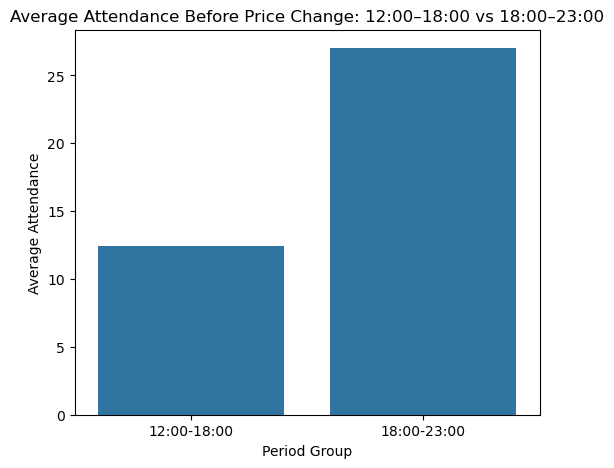

In [56]:
group_order = ["12:00-18:00", "18:00-23:00"]

plt.figure(figsize=(6, 5))
sns.barplot(
    data=q1_summary_grouped,
    x="period_group",
    y="avg_attendance",
    order=group_order
)
plt.title("Average Attendance Before Price Change: 12:00–18:00 vs 18:00–23:00")
plt.xlabel("Period Group")
plt.ylabel("Average Attendance")
plt.show()

### Interpretation

Before the pricing change, average attendance during 12:00–18:00 was clearly lower than attendance during 18:00–23:00, confirming that weekday afternoon hours were non-peak periods.

## 4. Question 2

Did attendance increase after the weekday non-peak price reduction?

### SQL Query

```sql
SELECT
  price_policy_phase,
  ROUND(AVG(attendance_count), 2) AS avg_attendance,
  SUM(attendance_count) AS total_attendance,
  COUNT(*) AS num_records
FROM `project-33891622-1fbb-47bb-9d2.badminton_analysis.court_usage_weekday`
WHERE time_slot IN ('12:00-15:00', '15:00-18:00')
GROUP BY price_policy_phase
ORDER BY price_policy_phase;

In [57]:
afternoon_df = df[df["time_slot"].isin(["12:00-15:00", "15:00-18:00"])]

q2_summary = (
    afternoon_df
    .groupby("price_policy_phase", as_index=False)
    .agg(
        avg_attendance=("attendance_count", "mean"),
        total_attendance=("attendance_count", "sum"),
        num_records=("attendance_count", "count")
    )
)

q2_summary["avg_attendance"] = q2_summary["avg_attendance"].round(2)

q2_summary

,price_policy_phase,avg_attendance,total_attendance,num_records
0,after_change,20.12,1730,86
1,before_change,12.47,1122,90


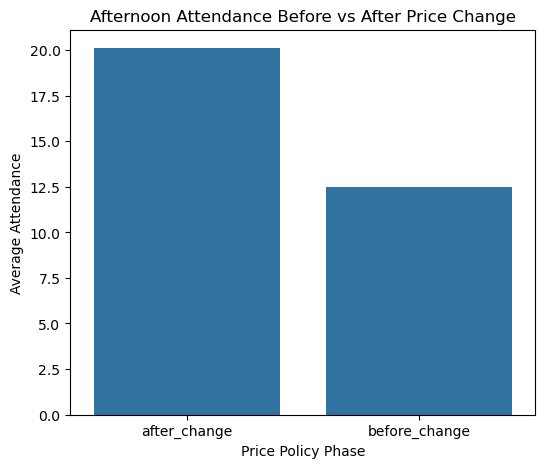

In [58]:
plt.figure(figsize=(6, 5))
sns.barplot(data=q2_summary, x="price_policy_phase", y="avg_attendance")
plt.title("Afternoon Attendance Before vs After Price Change")
plt.xlabel("Price Policy Phase")
plt.ylabel("Average Attendance")
plt.show()

### SQL Query

```sql
SELECT
  date,
  price_policy_phase,
  SUM(attendance_count) AS afternoon_attendance
FROM `project-33891622-1fbb-47bb-9d2.badminton_analysis.court_usage_weekday`
WHERE time_slot IN ('12:00-15:00', '15:00-18:00')
GROUP BY date, price_policy_phase
ORDER BY date;

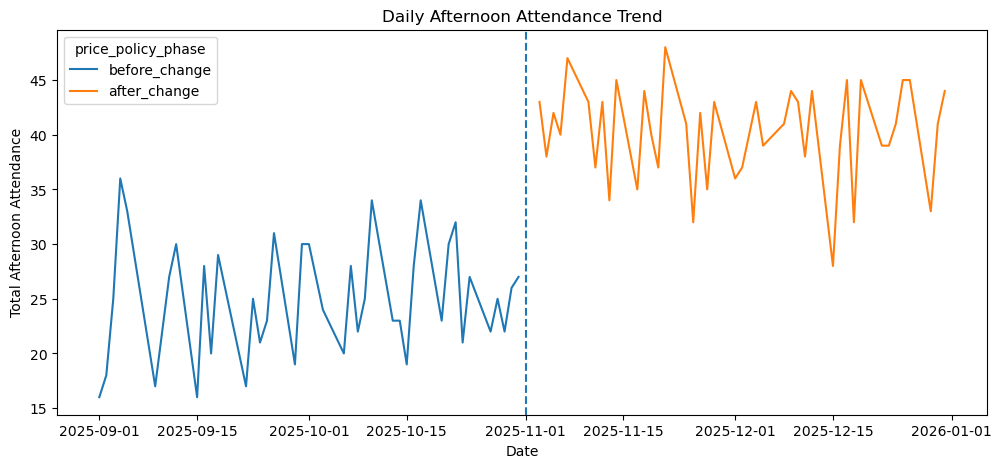

In [59]:
afternoon_daily = (
    afternoon_df.groupby(["date", "price_policy_phase"], as_index=False)["attendance_count"]
    .sum()
)

afternoon_daily["date"] = pd.to_datetime(afternoon_daily["date"])

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=afternoon_daily,
    x="date",
    y="attendance_count",
    hue="price_policy_phase")
plt.axvline(pd.to_datetime("2025-11-01"), linestyle="--")
plt.title("Daily Afternoon Attendance Trend")
plt.xlabel("Date")
plt.ylabel("Total Afternoon Attendance")
plt.show()

### Interpretation

After the weekday 12:00–18:00 price was reduced from $15 to $13, average afternoon attendance increased. The daily trend also shows a visible upward shift after the price change date.

## 5. Question 3

How did the pricing change affect revenue?

### SQL Query

```sql
SELECT
  price_policy_phase,
  ROUND(AVG(revenue_usd), 2) AS avg_revenue,
  ROUND(SUM(revenue_usd), 2) AS total_revenue
FROM `project-33891622-1fbb-47bb-9d2.badminton_analysis.court_usage_weekday`
GROUP BY price_policy_phase
ORDER BY price_policy_phase;

In [60]:
q3_summary = (
    df
    .groupby("price_policy_phase", as_index=False)
    .agg(
        avg_revenue=("revenue_usd", "mean"),
        total_revenue=("revenue_usd", "sum")
    )
)

q3_summary["avg_revenue"] = q3_summary["avg_revenue"].round(2)
q3_summary["total_revenue"] = q3_summary["total_revenue"].round(2)

q3_summary

,price_policy_phase,avg_revenue,total_revenue
0,after_change,335.70,57740
1,before_change,296.17,53310


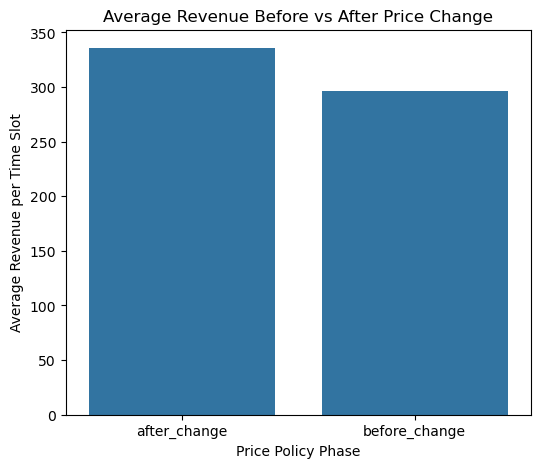

In [61]:
plt.figure(figsize=(6, 5))
sns.barplot(data=q3_summary, x="price_policy_phase", y="avg_revenue")
plt.title("Average Revenue Before vs After Price Change")
plt.xlabel("Price Policy Phase")
plt.ylabel("Average Revenue per Time Slot")
plt.show()

### SQL Query

```sql
SELECT
  price_policy_phase,
  ROUND(AVG(revenue_usd), 2) AS avg_revenue,
  ROUND(SUM(revenue_usd), 2) AS total_revenue
FROM `project-33891622-1fbb-47bb-9d2.badminton_analysis.court_usage_weekday`
WHERE time_slot IN ('12:00-15:00', '15:00-18:00')
GROUP BY price_policy_phase
ORDER BY price_policy_phase;

In [62]:
q3_afternoon = (
    afternoon_df
    .groupby("price_policy_phase", as_index=False)
    .agg(
        avg_revenue=("revenue_usd", "mean"),
        total_revenue=("revenue_usd", "sum")
    )
)

q3_afternoon["avg_revenue"] = q3_afternoon["avg_revenue"].round(2)
q3_afternoon["total_revenue"] = q3_afternoon["total_revenue"].round(2)

q3_afternoon

,price_policy_phase,avg_revenue,total_revenue
0,after_change,261.51,22490
1,before_change,187.00,16830


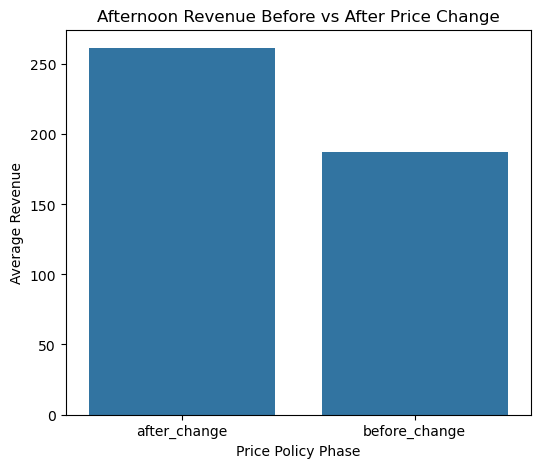

In [63]:
plt.figure(figsize=(6, 5))
sns.barplot(data=q3_afternoon, x="price_policy_phase", y="avg_revenue")
plt.title("Afternoon Revenue Before vs After Price Change")
plt.xlabel("Price Policy Phase")
plt.ylabel("Average Revenue")
plt.show()

### Interpretation

The increase in afternoon attendance was strong enough to offset the lower non-peak ticket price. In this synthetic scenario, both average afternoon revenue and overall average revenue increased after the pricing change.

## 6. Final Recommendation

The analysis suggests that lower weekday non-peak pricing can be an effective strategy for increasing afternoon traffic. Before the change, 12:00–18:00 had lower attendance than evening hours, confirming that it was a non-peak period. After reducing the non-peak price, attendance increased noticeably.

This strategy could help improve utilization during underused hours and create a more balanced demand pattern across the day.

A useful next step would be to test whether this pricing strategy remains effective across different seasons or under different demand conditions.